# l-v products (b=0 strip and densification)

Split out from `scan_load.ipynb` (Sections 8-9). Run `scan_load.ipynb`
through the QA cell first, then run this notebook in the same kernel
(or load the pickled `cell_combined`, `qa_flagged_set`, `v_lsr_overlap`,
`dv_kms` if running standalone).

In [1]:
# Load state from scan_load.ipynb if not already in the kernel.
import pickle
from pathlib import Path
import numpy as np
import astropy.coordinates as ac
import astropy.units as u_ast
import matplotlib.pyplot as plt

STATE_PATH = Path('artifacts/scan_load_state.pkl')
if 'cell_combined' not in dir():
    with open(STATE_PATH, 'rb') as f:
        _state = pickle.load(f)
    cell_combined = _state['cell_combined']
    qa_flagged_set = _state['qa_flagged_set']
    v_lsr_overlap = _state['v_lsr_overlap']
    dv_kms = _state['dv_kms']
    print(f'Loaded {STATE_PATH}: {len(cell_combined)} cells, '
          f'{len(qa_flagged_set)} QA-flagged')
else:
    print('Using in-kernel state from scan_load.ipynb')

Loaded artifacts/scan_load_state.pkl: 267 cells, 0 QA-flagged


## Beam-weighted Mollweide map of integrated HI intensity

Replaces the scatter-style integrated intensity map. Each pixel is a
Gaussian-beam-weighted average of pointings whose 3.4 deg HPBW partially
or fully overlaps it (cutoff at 2 * HPBW). Pixels with negligible total
weight are masked so unobserved sky stays blank.

/home/ikaros/projects/ay-121/.venv/lib/python3.12/site-packages/rtlsdr/__init__.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/home/ikaros/projects/ay-121/labs/04/plotters.py:557: RuntimeWarning: invalid value encountered in divide
  img = np.where(den > min_weight, num / den, np.nan).reshape(LL.shape)


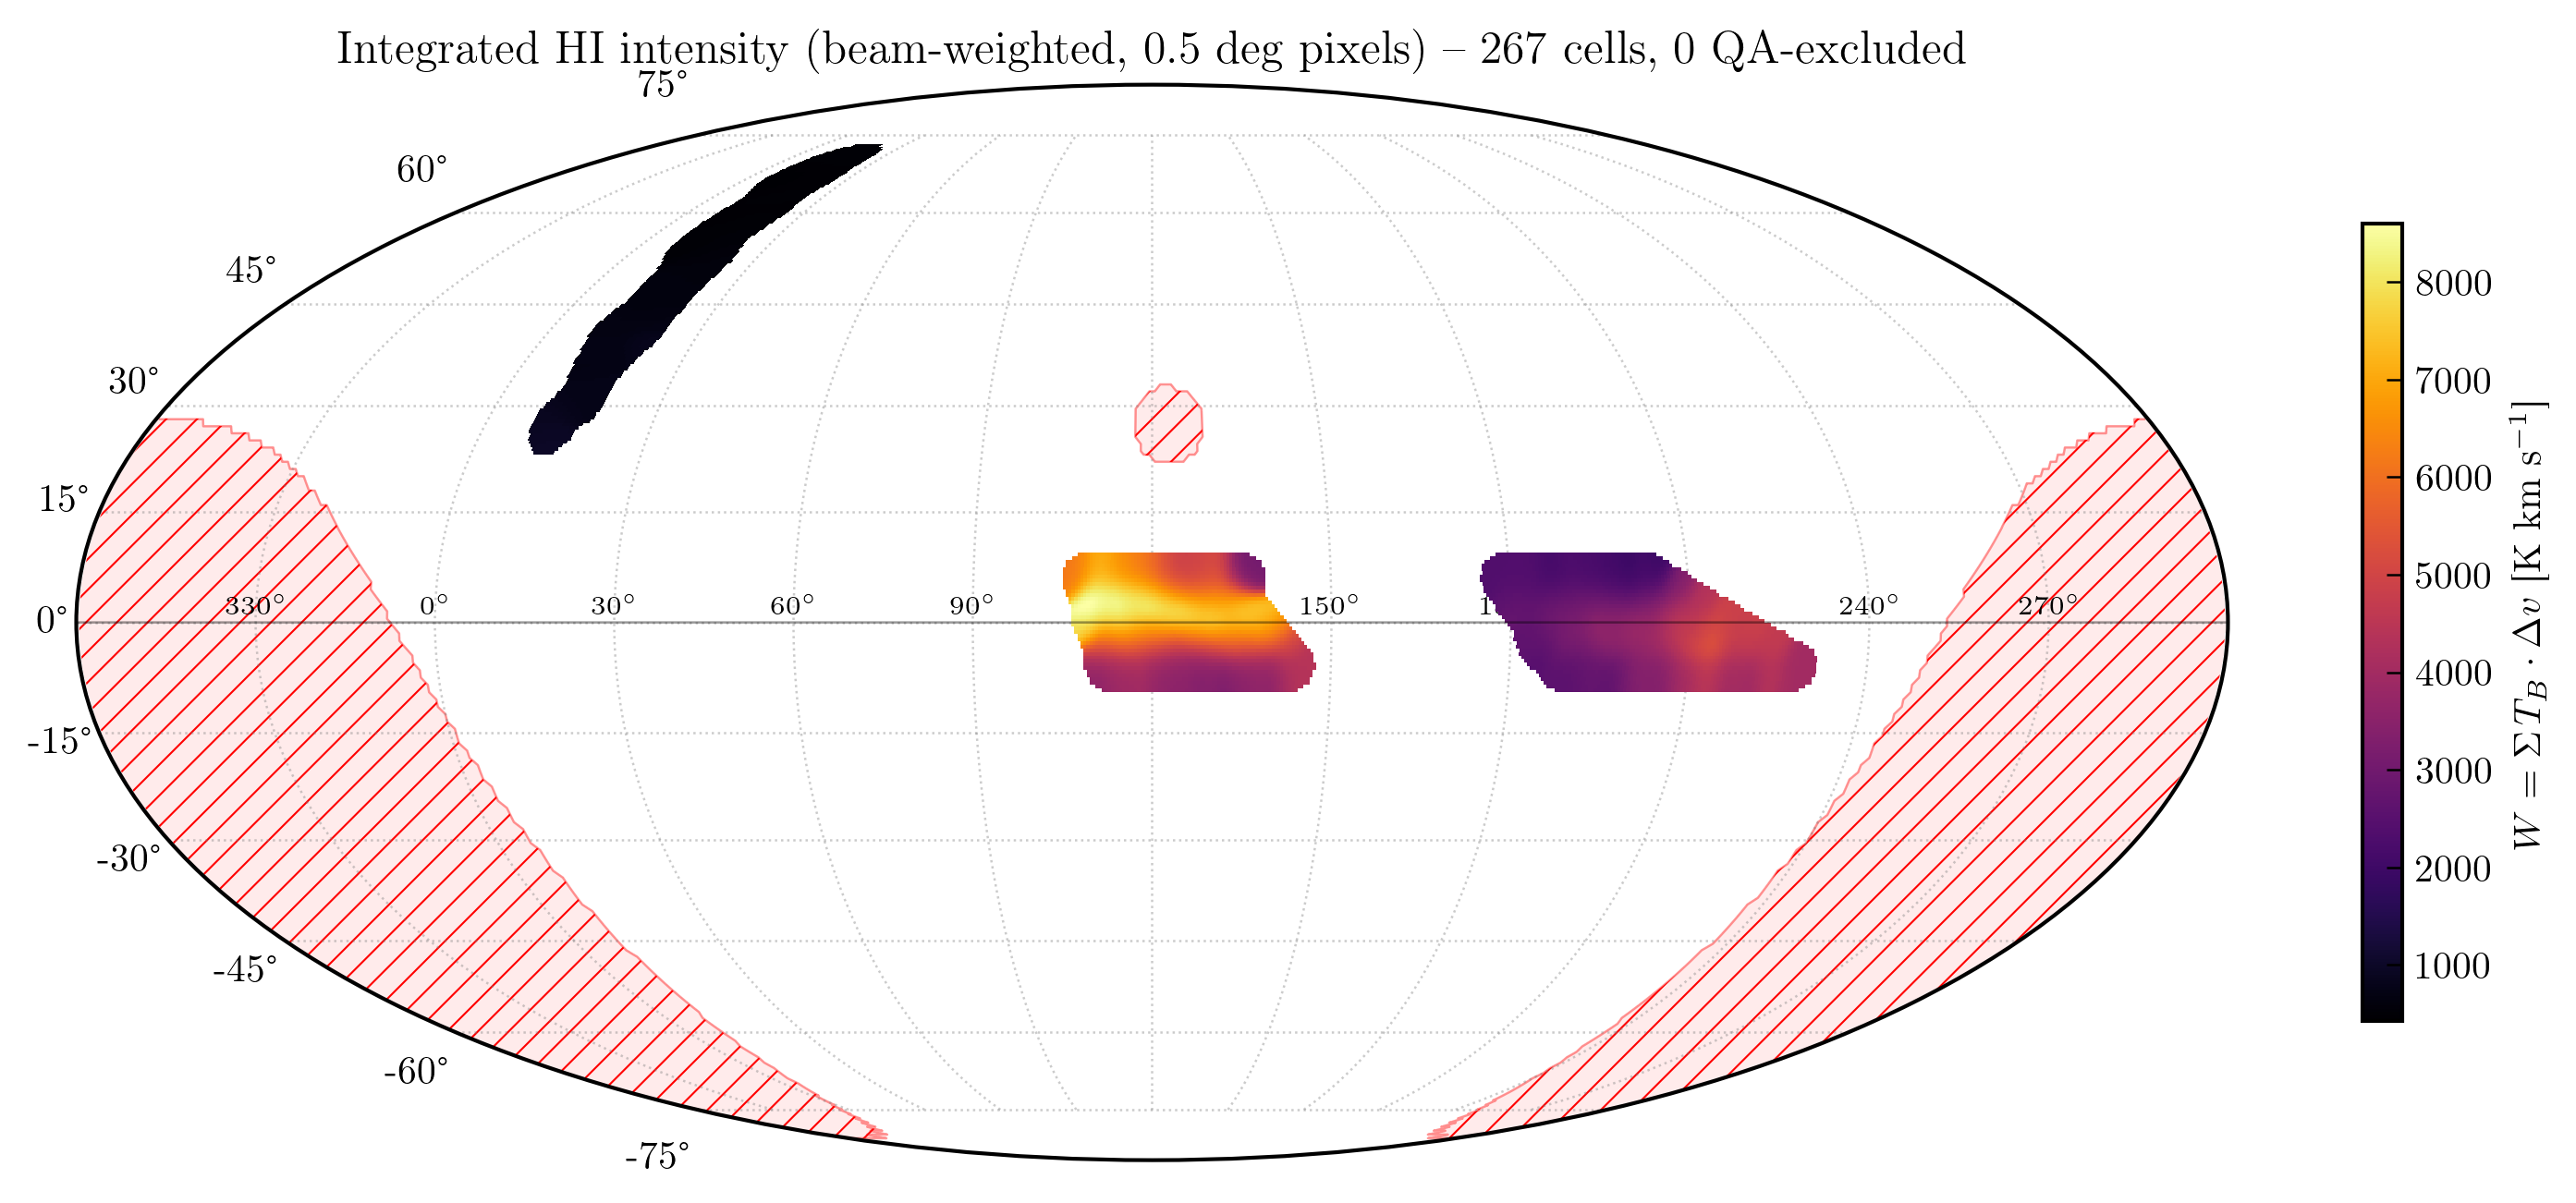

In [2]:
from plotters import plot_survey_mollweide_gridded

MOLL_CENTER_L = 120.0
HPBW_DEG = 3.4
PIXEL_DEG = 0.5      # Mollweide pixel size (deg); finer than HPBW for smooth fill
CUTOFF_HPBW = 2.0    # include pointings within this many HPBW of each pixel center

cell_keys_clean = [k for k in cell_combined if k not in qa_flagged_set]
gl_arr = np.array([k[0] for k in cell_keys_clean])
gb_arr = np.array([k[1] for k in cell_keys_clean])
TB_stack = np.array([cell_combined[k]['T_B'] for k in cell_keys_clean])
W = np.nansum(TB_stack, axis=1) * dv_kms
finite = np.isfinite(W)

fig, ax = plot_survey_mollweide_gridded(
    gl_arr[finite], gb_arr[finite], W[finite],
    center_l=MOLL_CENTER_L,
    cbar_label=r'$W = \Sigma\, T_B \cdot \Delta v$ [K km s$^{-1}$]',
    cmap='inferno',
    hpbw_deg=HPBW_DEG,
    pixel_deg=PIXEL_DEG,
    cutoff_hpbw=CUTOFF_HPBW,
    title=(f'Integrated HI intensity (beam-weighted, {PIXEL_DEG} deg pixels) -- '
           f'{int(finite.sum())} cells, {len(qa_flagged_set)} QA-excluded'),
)
plt.show()


## 8. Beam-weighted l-v strip at b ~ 0

Resample the (l, b ~ 0) cells onto a fine longitude grid using a Gaussian
beam kernel (sigma = HPBW / 2.355) over all cells with `|b| <= B_MAX_DEG`.
Each (l, v) pixel is `sum(w_i T_{B,i}(v)) / sum(w_i)` over contributing
cells, with weights cut off at `CUTOFF_HPBW * HPBW` and pixels with
total weight below `MIN_WEIGHT` masked. Pixels with no cell within
`KEEP_NEAR_HPBW * HPBW` are also masked, which automatically blanks the
never-observable wedge without explicit segment bookkeeping.

This collapses the previous Sections 8 (l-v at b=0 with b=+/-1 fallback)
and 9 (per-channel linear densification) into one step; `lv_image_dense`,
`l_fine`, `LV_DL_FINE`, and `never_observable_mask` are produced here for
Section 10.

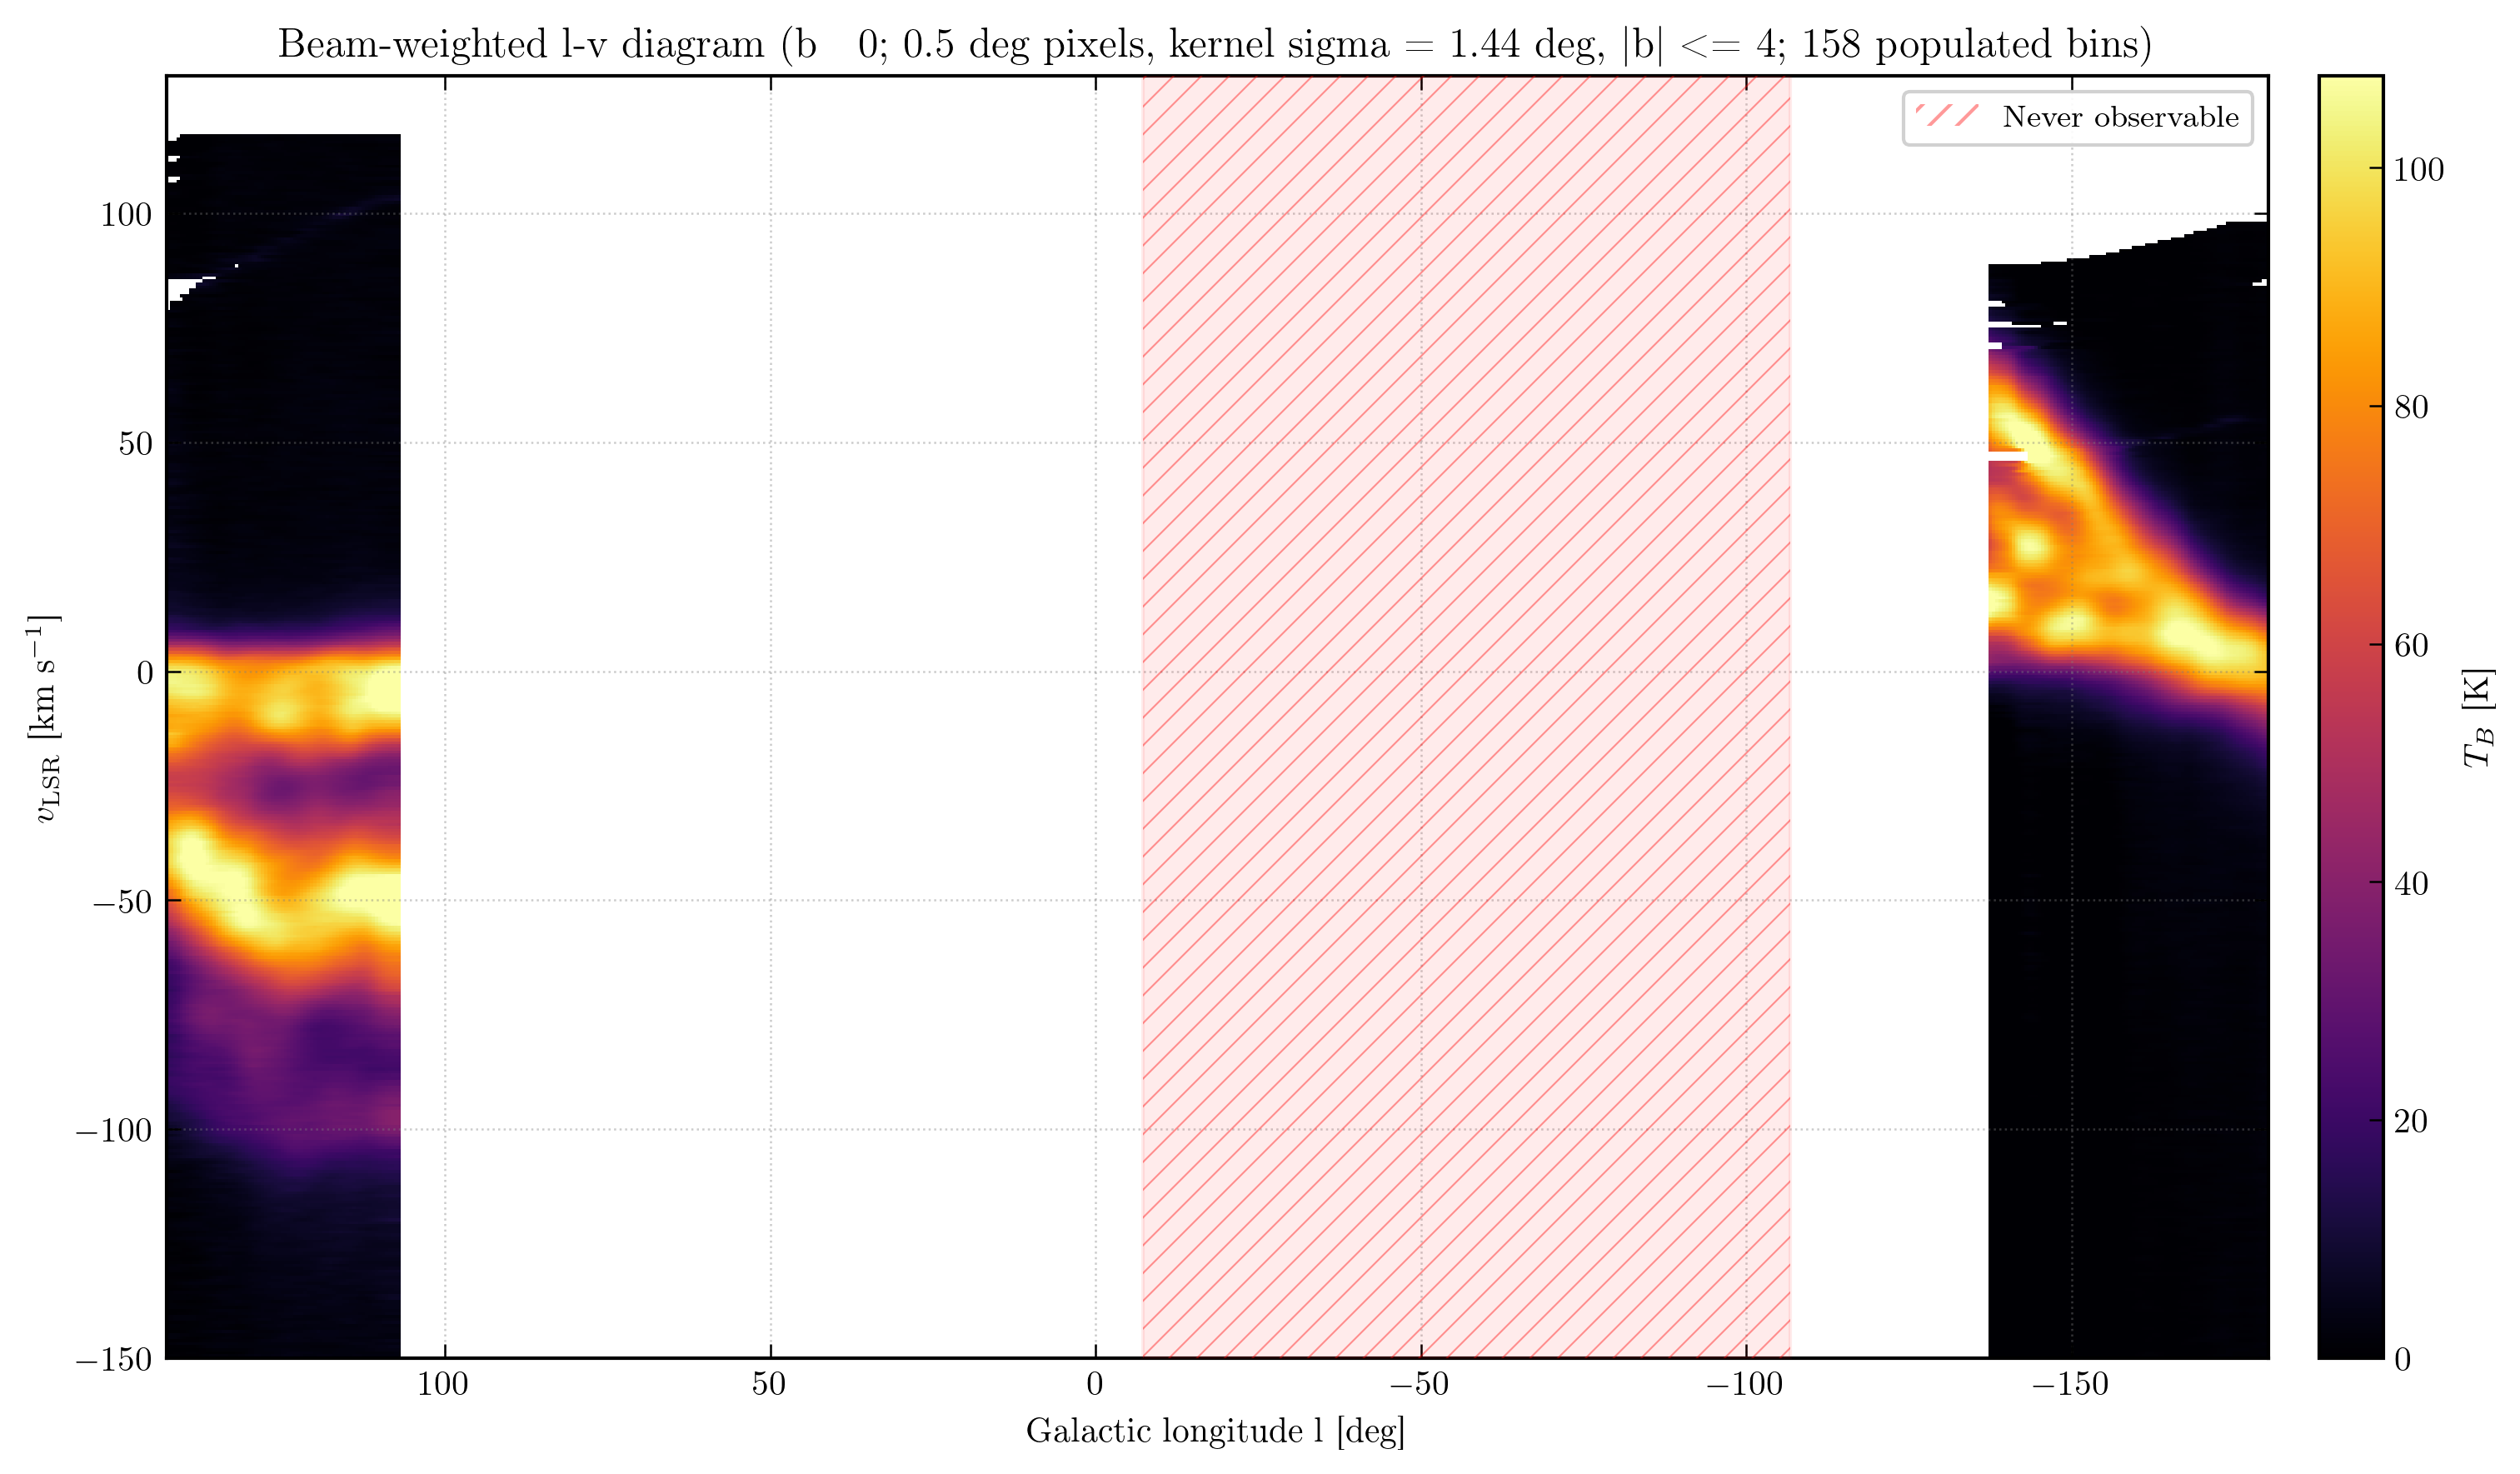

In [3]:
import matplotlib as mpl
import astropy.coordinates as ac
import astropy.units as u_ast

LV_DL_FINE = 0.5
LV_VMIN, LV_VMAX = -150, 130
HPBW_DEG = 3.4
SIGMA_DEG = HPBW_DEG / (2.0 * np.sqrt(2.0 * np.log(2.0)))
B_MAX_DEG = 4.0
CUTOFF_HPBW = 1.5
MIN_WEIGHT = 0.1
KEEP_NEAR_HPBW = 1.0

LEO_LAT_RAD = np.deg2rad(37.9183)
MIN_ALT_RAD = np.deg2rad(17.0)
MAX_ALT_RAD = np.deg2rad(83.0)
AZ_MIN_RAD = np.deg2rad(7.0)
AZ_MAX_RAD = np.deg2rad(348.0)
HA_STEPS = np.deg2rad(np.arange(0, 360, 1))


def never_observable_mask(l_arr, b_val):
    """True at each l in l_arr where (l, b_val) is never observable."""
    gc = ac.SkyCoord(l=l_arr * u_ast.deg,
                     b=np.full_like(l_arr, b_val, dtype=float) * u_ast.deg,
                     frame='galactic')
    dec_rad = np.deg2rad(gc.transform_to(ac.ICRS()).dec.deg)
    observable = np.zeros(len(l_arr), dtype=bool)
    for ha in HA_STEPS:
        sin_alt = (np.sin(LEO_LAT_RAD) * np.sin(dec_rad)
                   + np.cos(LEO_LAT_RAD) * np.cos(dec_rad) * np.cos(ha))
        alt = np.arcsin(np.clip(sin_alt, -1, 1))
        cos_az_num = np.sin(dec_rad) - np.sin(LEO_LAT_RAD) * sin_alt
        cos_az_den = np.cos(LEO_LAT_RAD) * np.cos(alt)
        with np.errstate(invalid='ignore', divide='ignore'):
            cos_az = np.clip(cos_az_num / cos_az_den, -1, 1)
        az = np.arccos(cos_az)
        az = np.where(np.sin(ha) > 0, 2 * np.pi - az, az)
        observable |= ((alt >= MIN_ALT_RAD) & (alt <= MAX_ALT_RAD)
                       & (az >= AZ_MIN_RAD) & (az <= AZ_MAX_RAD))
    return ~observable


# Contributing cells: |b| <= B_MAX_DEG, not QA-flagged
contrib_keys = [k for k in cell_combined
                if abs(k[1]) <= B_MAX_DEG and k not in qa_flagged_set]
gl_c = np.array([k[0] for k in contrib_keys])
gb_c = np.array([k[1] for k in contrib_keys])
TB_c = np.array([cell_combined[k]['T_B'] for k in contrib_keys])  # (N, nv)
gl_c_w = ((gl_c + 180.0) % 360.0) - 180.0

# Fine longitude grid covering the data extent
l_lo = np.floor(gl_c_w.min() / LV_DL_FINE) * LV_DL_FINE
l_hi = np.ceil(gl_c_w.max() / LV_DL_FINE) * LV_DL_FINE
l_fine = np.arange(l_lo, l_hi + LV_DL_FINE, LV_DL_FINE)

# Great-circle distance from each pixel (at b=0) to each cell
sigma_rad = np.deg2rad(SIGMA_DEG)
cutoff_rad = np.deg2rad(CUTOFF_HPBW * HPBW_DEG)
near_rad = np.deg2rad(KEEP_NEAR_HPBW * HPBW_DEG)
G_l = np.deg2rad(l_fine)[:, None]                      # (M, 1)
P_l = np.deg2rad(gl_c_w)[None, :]                      # (1, N)
P_b = np.deg2rad(gb_c)[None, :]                        # (1, N)
cosang = np.clip(np.cos(P_b) * np.cos(G_l - P_l), -1.0, 1.0)
theta = np.arccos(cosang)                              # (M, N)
w = np.exp(-0.5 * (theta / sigma_rad) ** 2)
w[theta > cutoff_rad] = 0.0

# NaN-aware weighted average across cells, per (pixel, channel)
finite_TB = np.isfinite(TB_c)                          # (N, nv)
TB_safe = np.where(finite_TB, TB_c, 0.0)
w_T = w @ TB_safe                                      # (M, nv)
w_S = w @ finite_TB.astype(float)                      # (M, nv)
with np.errstate(invalid='ignore', divide='ignore'):
    lv_image_dense = np.where(w_S > MIN_WEIGHT, w_T / w_S, np.nan).T  # (nv, M)

# Wedge guard: blank pixels with no cell within KEEP_NEAR_HPBW * HPBW
no_near = theta.min(axis=1) > near_rad
lv_image_dense[:, no_near] = np.nan

# Edges for pcolormesh
v_step = v_lsr_overlap[1] - v_lsr_overlap[0]
v_edges = np.concatenate([
    [v_lsr_overlap[0] - 0.5 * v_step],
    0.5 * (v_lsr_overlap[:-1] + v_lsr_overlap[1:]),
    [v_lsr_overlap[-1] + 0.5 * v_step],
])
l_edges_fine = np.concatenate([
    [l_fine[0] - 0.5 * LV_DL_FINE],
    0.5 * (l_fine[:-1] + l_fine[1:]),
    [l_fine[-1] + 0.5 * LV_DL_FINE],
])

finite_vals = lv_image_dense[np.isfinite(lv_image_dense)]
vmin = max(0.0, np.nanpercentile(finite_vals, 1)) if finite_vals.size else 0.0
vmax = np.nanpercentile(finite_vals, 99) if finite_vals.size else 1.0

fig, ax = plt.subplots(figsize=(11, 6))
pcm = ax.pcolormesh(l_edges_fine, v_edges, lv_image_dense,
                    cmap='inferno', vmin=vmin, vmax=vmax, shading='flat')

# Never-observable wedge overlay
inacc = never_observable_mask(l_fine.astype(float) % 360.0, 0.0)
runs = []
k = 0
while k < len(l_fine):
    if inacc[k]:
        k0 = k
        while k < len(l_fine) and inacc[k]:
            k += 1
        runs.append((l_edges_fine[k0], l_edges_fine[k]))
    else:
        k += 1
first_patch = True
for l0, l1 in runs:
    label = 'Never observable' if first_patch else None
    ax.fill_between([l0, l1], LV_VMIN, LV_VMAX,
                    color='red', alpha=0.08, zorder=3)
    with mpl.rc_context({'hatch.color': 'red', 'hatch.linewidth': 0.5}):
        ax.fill_between([l0, l1], LV_VMIN, LV_VMAX,
                        facecolor='none', edgecolor='red', linewidth=0,
                        hatch='///', alpha=0.4, zorder=4, label=label)
    first_patch = False

ax.set_xlabel('Galactic longitude l [deg]')
ax.set_ylabel(r'$v_{\rm LSR}$ [km s$^{-1}$]')
ax.set_ylim(LV_VMIN, LV_VMAX)
ax.invert_xaxis()
n_pop = int(np.isfinite(lv_image_dense).any(axis=0).sum())
ax.set_title(f'Beam-weighted l-v diagram (b ~ 0; '
             f'{LV_DL_FINE} deg pixels, kernel sigma = {SIGMA_DEG:.2f} deg, '
             f'|b| <= {B_MAX_DEG:.0f}; {n_pop} populated bins)')
if runs:
    ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
cbar = fig.colorbar(pcm, ax=ax, pad=0.02)
cbar.set_label(r'$T_B$ [K]')
plt.tight_layout()
plt.show()